# Results - Judge Comparative

The goal of this notebook is to anbalyse the results of the ROUGE-L collections agains the binary judge classifications through the plot of a ROC-AUC curve.  
In this scenario the "true_labesl" will be the evaluations from the judge and the probabilities will be the ROUGE-L scores.



In [1]:
import polars as pl
import json
from sklearn import metrics
import matplotlib.pyplot as plt
import os


In [ ]:
def compute_roc_auc_judge_vs_rougel(judge_df, rougel_df):
    """
    Compute and plot ROC-AUC curve comparing judge evaluations against ROUGE-L scores.
    
    Parameters:
    -----------
    judge_df : polars.DataFrame
        Judge dataframe with columns: collection_idx, test_idx, evaluation
    rougel_df : polars.DataFrame
        ROUGE-L dataframe with columns: collection_idx, test_idx, rougel
    
    Returns:
    --------
    float : ROC-AUC score
    """
    # Filter null values and sort
    filtered_judge_df = judge_df.filter(pl.col("evaluation").is_not_null()).sort("collection_idx", "test_idx")
    
    # Join with rougel_df to ensure alignment
    merged_df = filtered_judge_df.join(
        rougel_df.rename({"evaluation": "rougel"}),
        on=["collection_idx", "test_idx"],
        how="inner"
    ).sort("collection_idx", "test_idx")
    
    # Extract labels and scores
    y_true = merged_df["evaluation"].to_list()
    y_scores = merged_df.select(pl.col("rougel")).to_series().to_list()
    
    # Calculate ROC-AUC
    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_scores)
    roc_auc = metrics.auc(fpr, tpr)
    
    # Plot ROC curve
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curve: Judge Evaluation vs ROUGE-L Scores')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    
    return roc_auc



# Experiment - Instruction Optional Response (only if present in context) 

## Consolidate Rouge-L collections

In [3]:
_train_df= []

for file in os.listdir("../experiment_81_opt/datamodels/collections/train/"):
    if file.endswith(".feather"):
        _train_df.append(pl.read_ipc(os.path.join("../experiment_81_opt/datamodels/collections/train/", file)))


exp1_train_df = pl.concat(_train_df).sort("collection_idx", "test_idx")


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [4]:
exp1_train_df.head()

collection_idx,test_idx,input,evaluation
i64,i64,"array[i64, 100]",f64
0,0,"[0, 0, … 1]",0.0
0,1,"[0, 0, … 1]",0.0
0,2,"[0, 0, … 1]",0.0
0,3,"[0, 0, … 1]",0.5
0,4,"[0, 0, … 1]",0.0


In [5]:
exp1_train_df.filter(pl.col("evaluation")>0).group_by("test_idx").agg(pl.count())

/tmp/ipykernel_429988/2229789381.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp1_train_df.filter(pl.col("evaluation")>0).group_by("test_idx").agg(pl.count())


test_idx,count
i64,u32
3,298
4,99
6,10
8,8
0,215
9,2
1,60
7,15


## Naive Binary Judge

In [6]:
exp1_naive_judge = pl.read_ipc("../judge_collections/train_opt/naive_judge.feather").sort("collection_idx", "test_idx")

In [7]:
exp1_naive_judge.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_429988/1177987981.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp1_naive_judge.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
1,1004
null,5208
0,13788


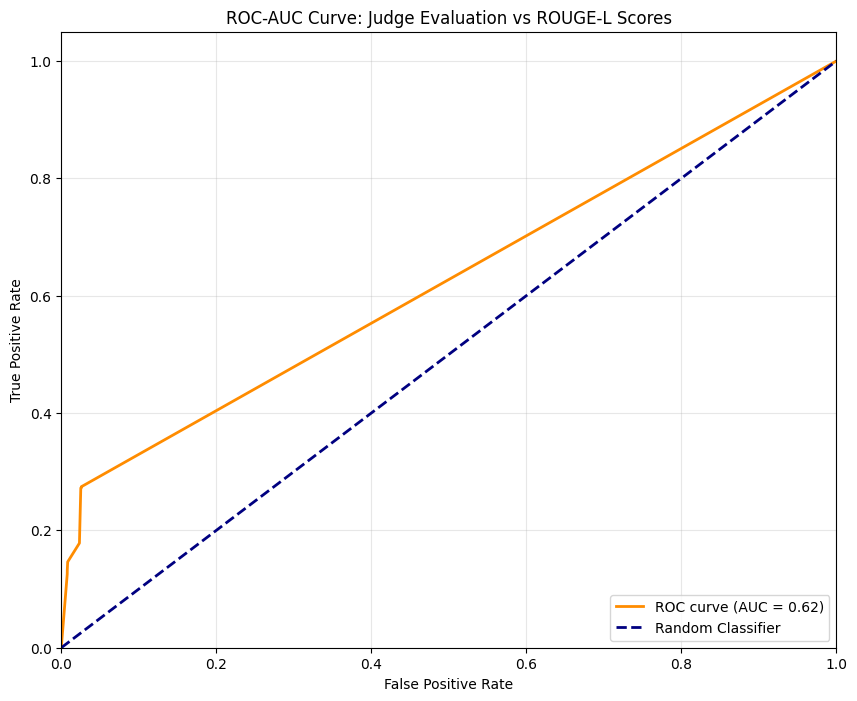

ROC-AUC Score: 0.6243


In [8]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(exp1_naive_judge, exp1_train_df)

## Naive Binary Recall Judge

In [9]:
exp1_recall_naive = pl.read_ipc("../judge_collections/train_opt/recall_naive_judge.feather").sort("collection_idx", "test_idx")

In [10]:
exp1_recall_naive.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_429988/1410066867.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp1_recall_naive.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
null,3626
0,15386
1,988


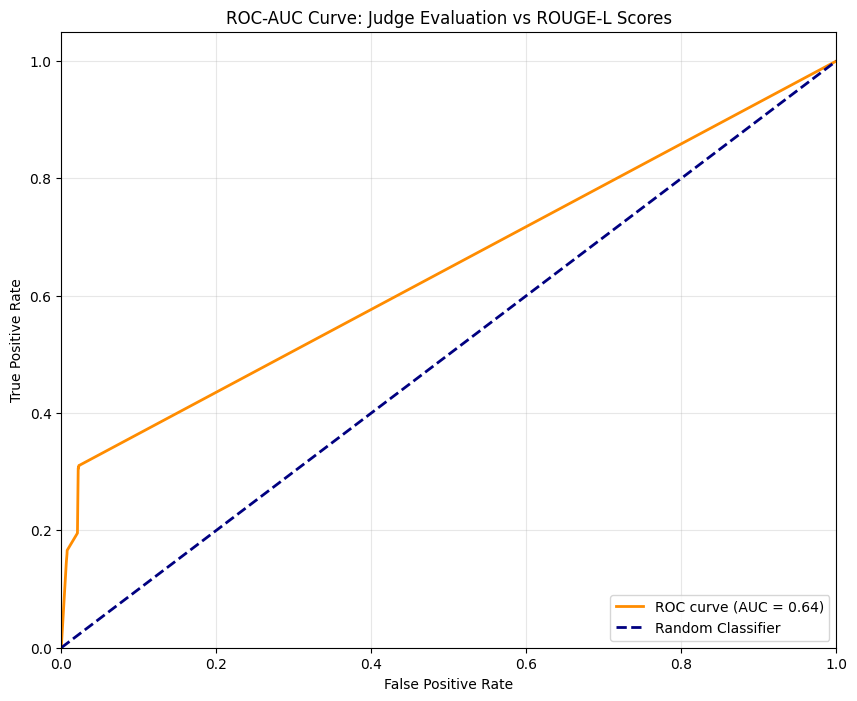

ROC-AUC Score: 0.6439


In [11]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(exp1_recall_naive, exp1_train_df)

## Pairwise ZeroShot

In [12]:
exp1_pairwise_zeroshot = pl.read_ipc("../judge_collections/train_opt/pairwise_zeroshot_judge.feather").sort("collection_idx", "test_idx")

In [13]:
exp1_pairwise_zeroshot.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_429988/2926918456.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp1_pairwise_zeroshot.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
null,5086
1,5542
0,9372


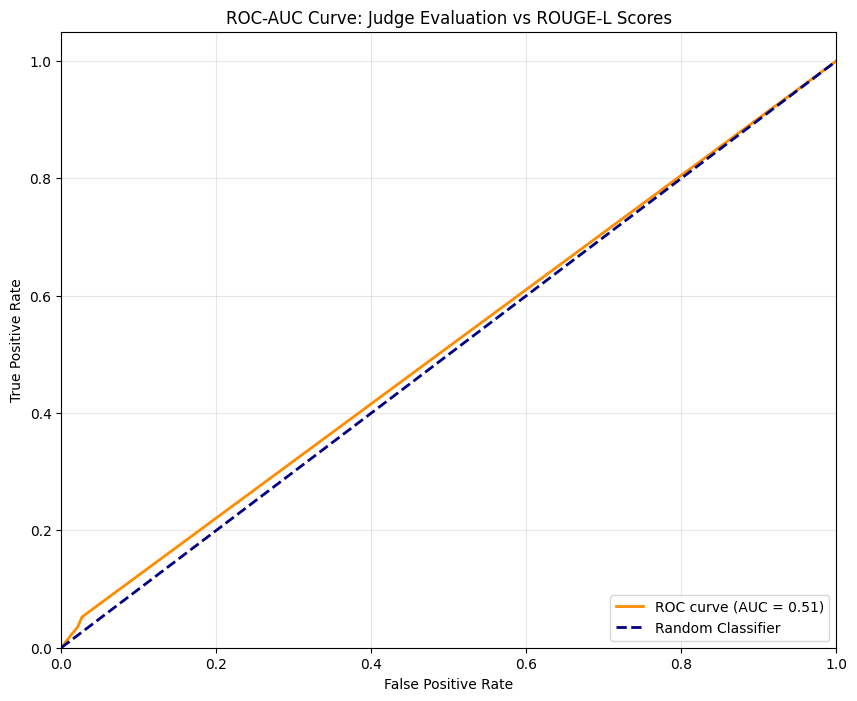

ROC-AUC Score: 0.5128


In [14]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(exp1_pairwise_zeroshot, exp1_train_df)

## Pairwise RAG

In [15]:
exp1_pairwise_rag = pl.read_ipc("../judge_collections/train_opt/pairwise_rag_judge.feather").sort("collection_idx", "test_idx")

In [16]:
exp1_pairwise_zeroshot.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_429988/2926918456.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp1_pairwise_zeroshot.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
1,5542
0,9372
null,5086


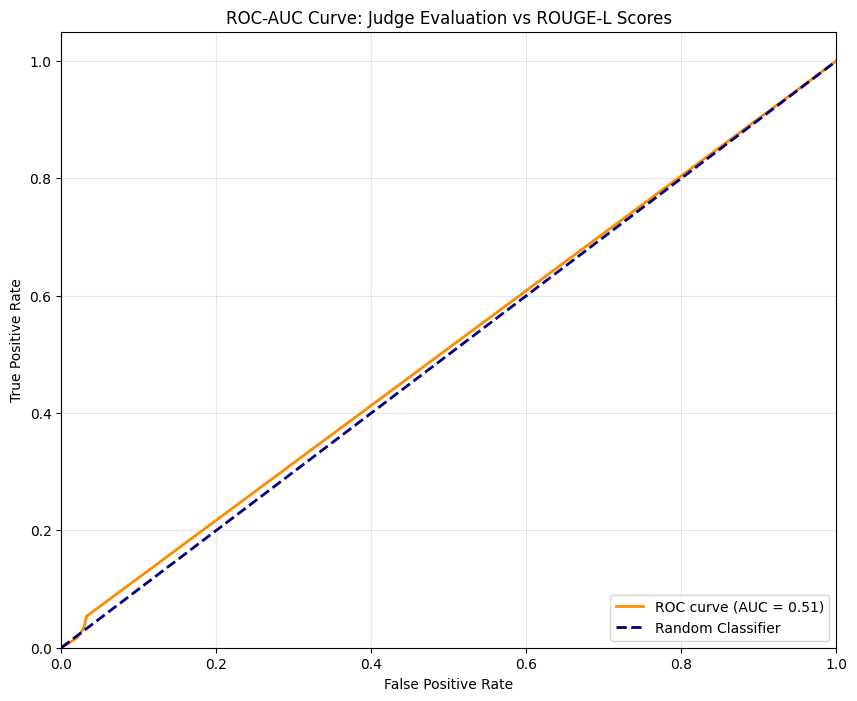

ROC-AUC Score: 0.5102


In [17]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(exp1_pairwise_rag, exp1_train_df)

# Experiment - Instruction  without specification of Context Usage

## Consolidate Rouge-L collections

In [18]:
train_df= []

for file in os.listdir("../experiment_81/datamodels/collections/train/"):
    if file.endswith(".feather"):
        train_df.append(pl.read_ipc(os.path.join("../experiment_81/datamodels/collections/train/", file)))


exp2_train_df = pl.concat(train_df).sort("collection_idx", "test_idx")


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [19]:
exp2_train_df.head()

collection_idx,test_idx,input,evaluation
i64,i64,"array[i64, 100]",f64
0,0,"[0, 0, … 1]",0.285714
0,1,"[0, 0, … 1]",0.0
0,2,"[0, 0, … 1]",0.0
0,3,"[0, 0, … 1]",1.0
0,4,"[0, 0, … 1]",0.0


In [20]:
exp2_train_df.filter(pl.col("evaluation")>0).group_by("test_idx").agg(pl.count())

/tmp/ipykernel_429988/917964492.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp2_train_df.filter(pl.col("evaluation")>0).group_by("test_idx").agg(pl.count())


test_idx,count
i64,u32
8,184
0,638
1,258
4,426
2,17
6,652
5,40
9,20
3,806


## Naive Binary Judge

In [21]:
exp2_naive_judge = pl.read_ipc("../judge_collections/train/naive_judge.feather").sort("collection_idx", "test_idx")

In [22]:
exp2_naive_judge.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_429988/783283470.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp2_naive_judge.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
0,10814
1,7021
null,2165


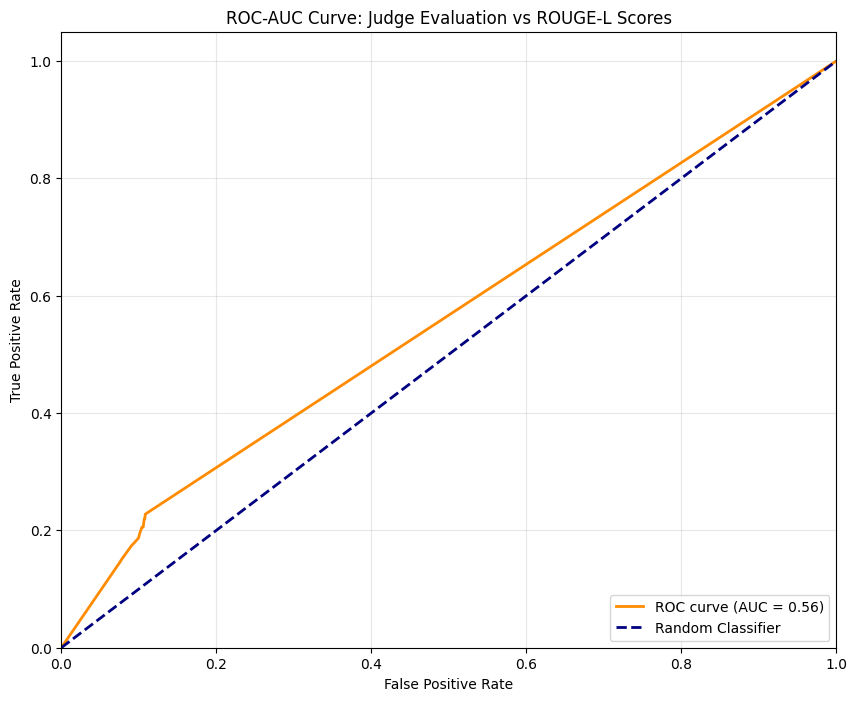

ROC-AUC Score: 0.5586


In [23]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(exp2_naive_judge, exp2_train_df)

## Naive Binary Recall Judge

In [24]:
exp2_recall_naive = pl.read_ipc("../judge_collections/train/recall_naive_judge.feather").sort("collection_idx", "test_idx")

In [25]:
exp2_recall_naive.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_429988/1309464338.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp2_recall_naive.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
null,1166
0,9413
1,9421


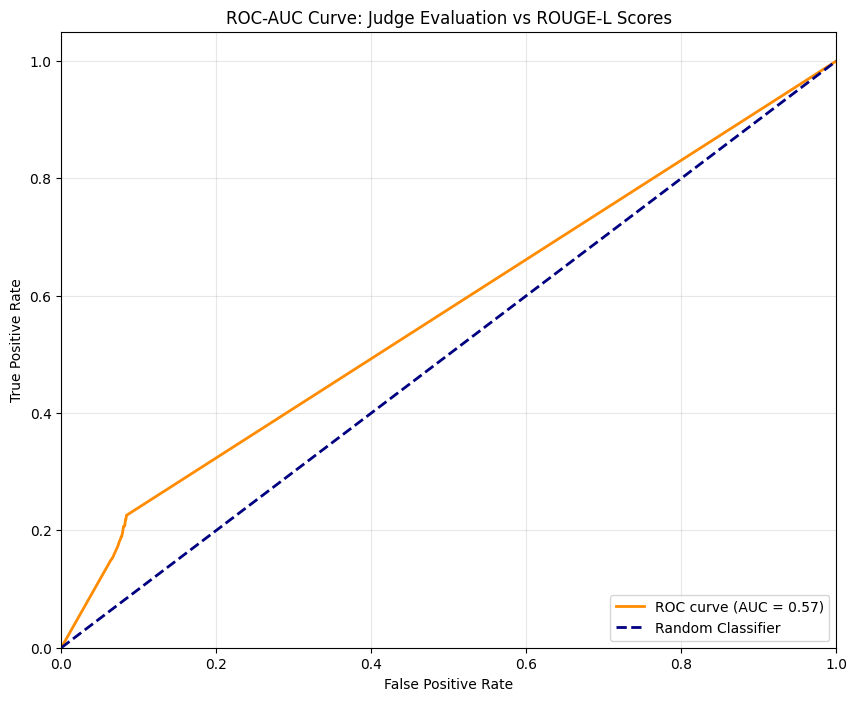

ROC-AUC Score: 0.5697


In [26]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(exp2_recall_naive, exp2_train_df)

## Pairwise ZeroShot

In [27]:
exp2_pairwise_zeroshot = pl.read_ipc("../judge_collections/train/pairwise_zeroshot_judge.feather").sort("collection_idx", "test_idx")

In [28]:
exp2_pairwise_zeroshot.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_429988/3584713561.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp2_pairwise_zeroshot.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
1,7986
null,667
0,11347


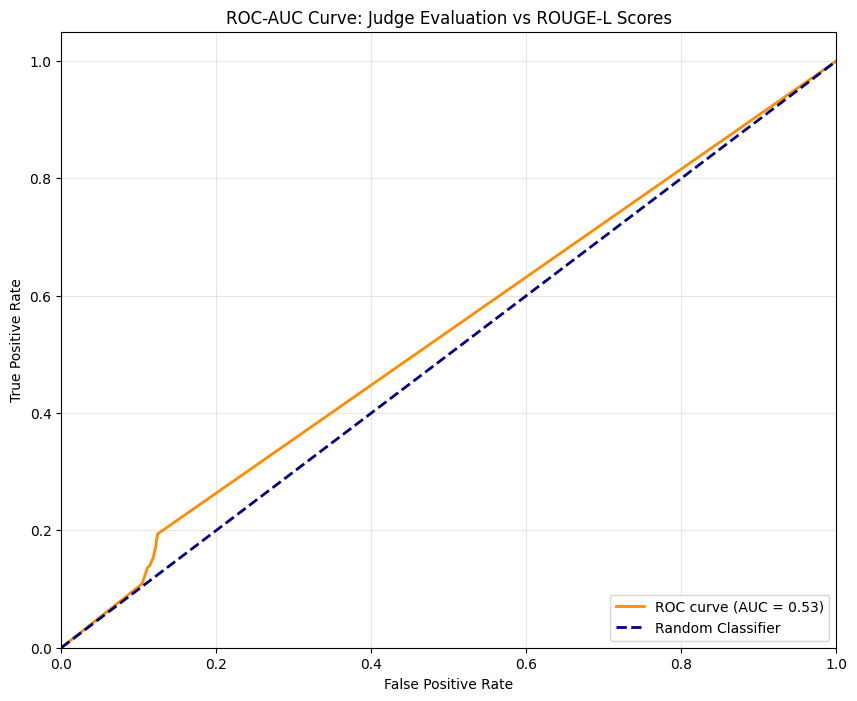

ROC-AUC Score: 0.5313


In [29]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(exp2_pairwise_zeroshot, exp2_train_df)

## Pairwise RAG

In [30]:
exp2_pairwise_rag = pl.read_ipc("../judge_collections/train/pairwise_rag_judge.feather").sort("collection_idx", "test_idx")

In [31]:
exp2_pairwise_zeroshot.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_429988/3584713561.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp2_pairwise_zeroshot.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
null,667
0,11347
1,7986


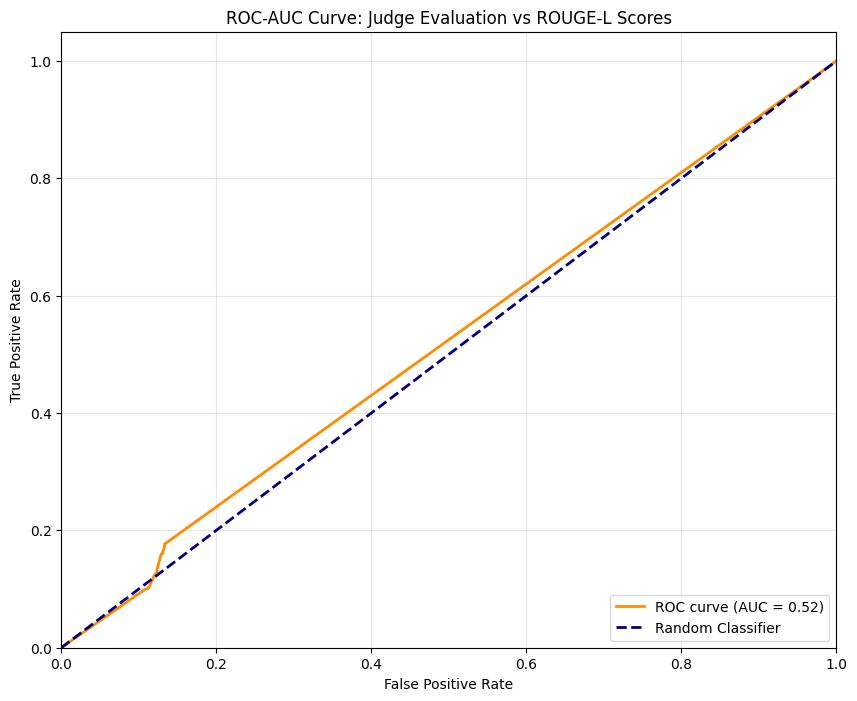

ROC-AUC Score: 0.5185


In [32]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(exp2_pairwise_rag, exp2_train_df)

# Experiment - Rouge Instructions without Context Specification with optional in response

## Consolidate Rouge-L collections

## Naive Binary Judge

In [33]:
exp3_naive_judge = pl.read_ipc("../judge_collections/train_opt/naive_judge.feather").sort("collection_idx", "test_idx")

In [34]:
exp3_naive_judge.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_429988/3383553080.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp3_naive_judge.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
1,1004
0,13788
null,5208


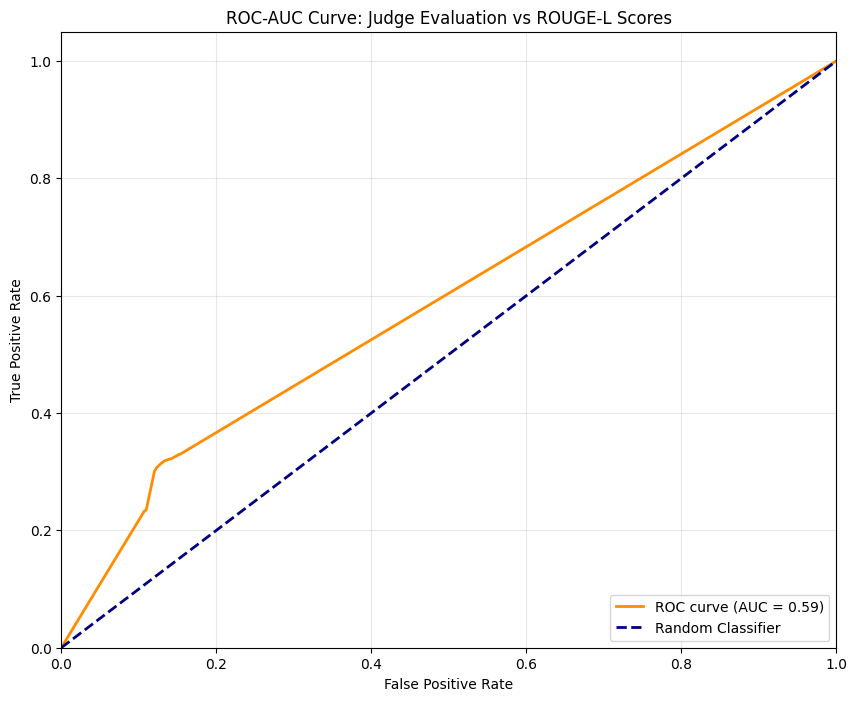

ROC-AUC Score: 0.5894


In [35]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(exp3_naive_judge, exp2_train_df)

## Naive Binary Recall Judge

In [36]:
exp3_recall_naive_judge_df = pl.read_ipc("../judge_collections/train_opt/recall_naive_judge.feather").sort("collection_idx", "test_idx")

In [37]:
exp3_recall_naive_judge_df.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_429988/1232727256.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp3_recall_naive_judge_df.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
null,3626
1,988
0,15386


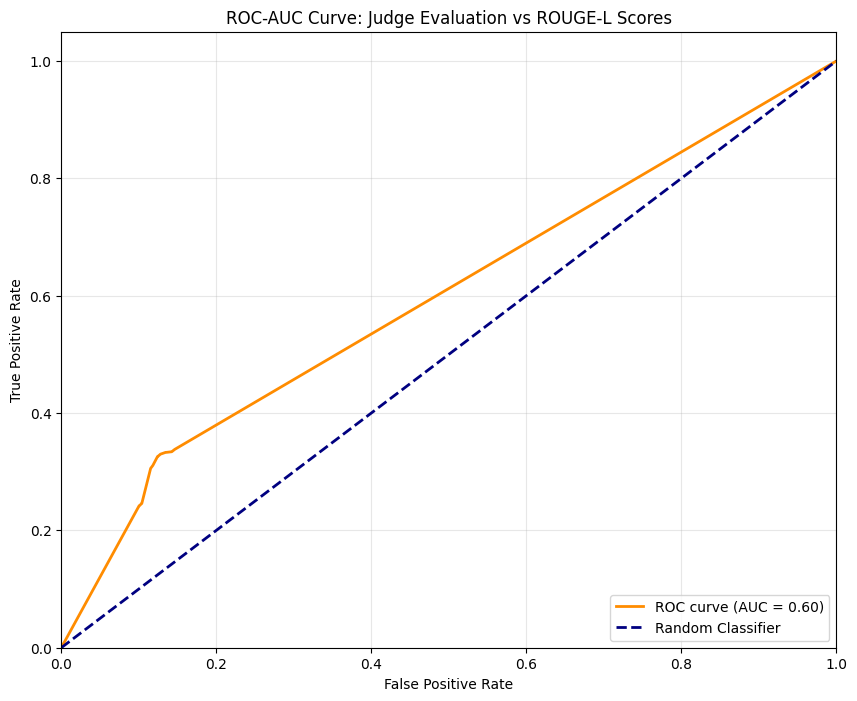

ROC-AUC Score: 0.5974


In [38]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(exp3_recall_naive_judge_df, exp2_train_df)

## Pairwise ZeroShot

In [39]:
exp3_pairwise_zeroshot_df = pl.read_ipc("../judge_collections/train_opt/pairwise_zeroshot_judge.feather").sort("collection_idx", "test_idx")

In [40]:
exp3_pairwise_zeroshot_df.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_429988/3667292201.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp3_pairwise_zeroshot_df.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
null,5086
1,5542
0,9372


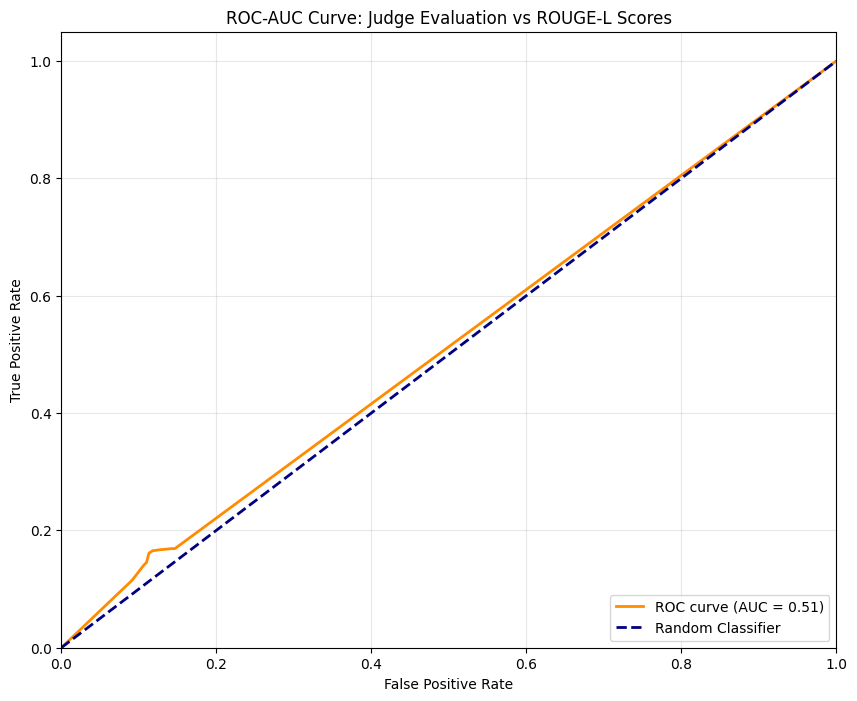

ROC-AUC Score: 0.5125


In [41]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(exp3_pairwise_zeroshot_df, exp2_train_df)

## Pairwise RAG

In [42]:
exp3_pairwise_rag_df = pl.read_ipc("../judge_collections/train_opt/pairwise_rag_judge.feather").sort("collection_idx", "test_idx")

In [43]:
exp3_pairwise_zeroshot_df.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_429988/3667292201.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp3_pairwise_zeroshot_df.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
null,5086
0,9372
1,5542


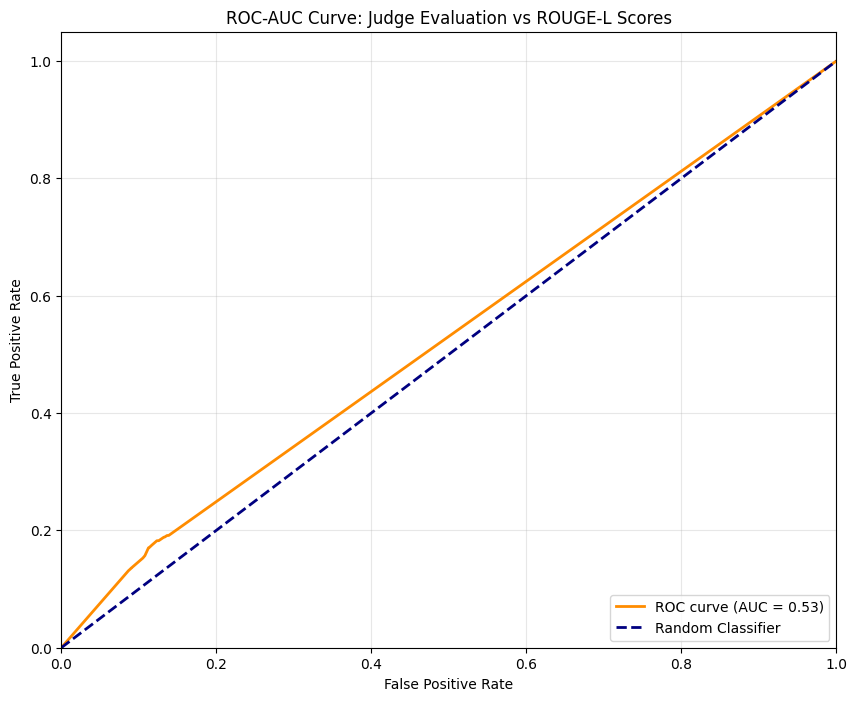

ROC-AUC Score: 0.5274


In [44]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(exp3_pairwise_rag_df, exp2_train_df)